<a href="https://colab.research.google.com/github/Mystery-Oh/2026-1_CV/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow

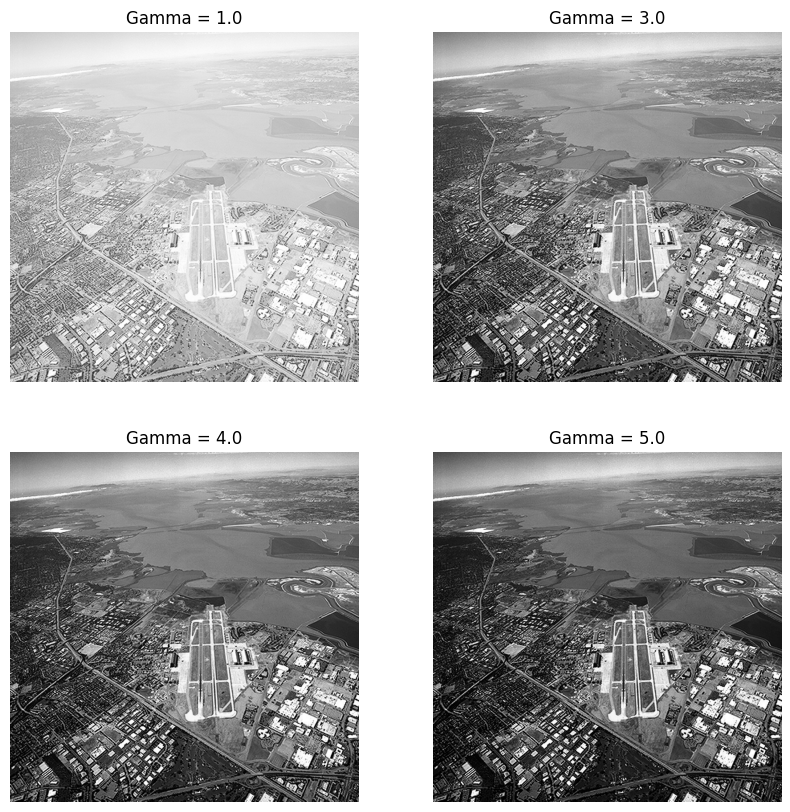

In [ ]:
# HW 2-1

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HW2_data/hw2-1.tif', cv2.IMREAD_GRAYSCALE)

img_norm = img / 255.0
gamma_values = [1.0, 3.0, 4.0, 5.0]

plt.figure(figsize=(10, 10))

for i, gamma in enumerate(gamma_values):
    res = np.power(img_norm, gamma)
    res = np.uint8(res * 255)

    plt.subplot(2, 2, i + 1)
    plt.imshow(res, cmap='gray')
    plt.title(f'Gamma = {gamma}')
    plt.axis('off')

plt.show()

#

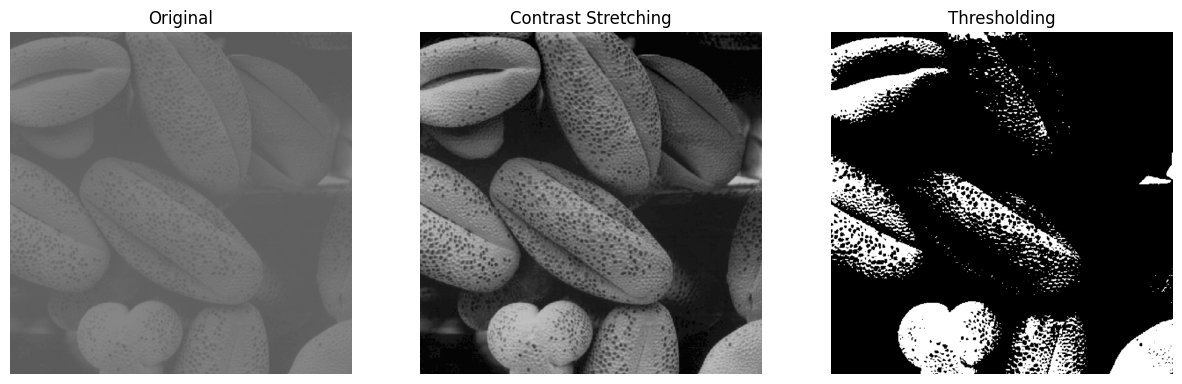

In [54]:
# HW 2-2

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HW2_data/hw2-2.tif', cv2.IMREAD_GRAYSCALE)

def piecewise_transform(img, r1, s1, r2, s2):
    img_float = img.astype(float)
    res = np.zeros_like(img_float)

    # 0 <= r < r1
    idx1 = img_float < r1
    if r1 > 0:
        res[idx1] = (s1 / r1) * img_float[idx1]

    # r1 <= r <= r2
    idx2 = (img_float >= r1) & (img_float <= r2)
    if r2 > r1:
        res[idx2] = ((s2 - s1) / (r2 - r1)) * (img_float[idx2] - r1) + s1

    # r2 < r <= 255
    idx3 = img_float > r2
    if r2 < 255:
        res[idx3] = ((255 - s2) / (255 - r2)) * (img_float[idx3] - r2) + s2

    return np.clip(res, 0, 255).astype(np.uint8)

res_stretch = piecewise_transform(img, r1=90, s1=0, r2=150, s2=255)

res_thresh = piecewise_transform(img, r1=120, s1=0, r2=120, s2=255)

titles = ['Original', 'Contrast Stretching', 'Thresholding']
images = [img, res_stretch, res_thresh]

plt.figure(figsize=(15, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis('off')

plt.show()



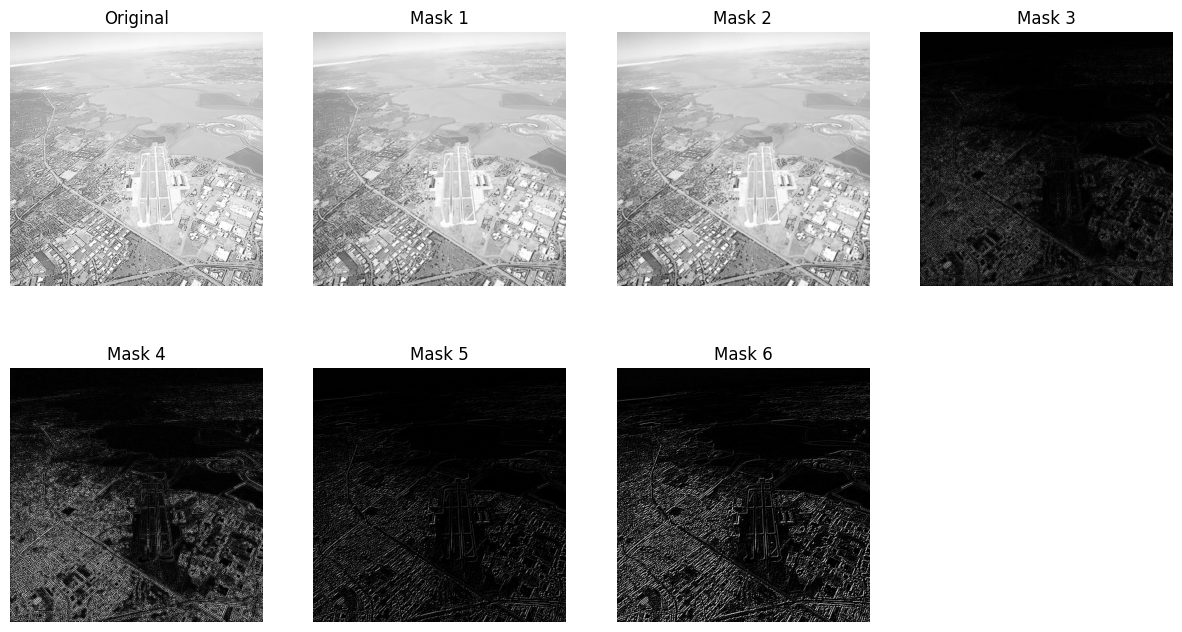

In [48]:
# HW 2-3

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HW2_data/hw2-3.png', cv2.IMREAD_GRAYSCALE)

mask1 = np.ones((3, 3), np.float32) / 9.0

mask2 = np.array([[0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
                  [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
                  [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
                  [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
                  [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]], dtype = np.float32)

mask3 = np.array([[0, -1, 0],
                  [-1, 4, -1],
                  [0, -1, 0]], dtype = np.float32)

mask4 = np.array([[-1, -1, -1],
                  [-1,  8, -1],
                  [-1, -1, -1]], dtype = np.float32)

mask5 = np.array([[-1, 0, 0],
                  [0,  0, 0],
                  [0, 0, 1]], dtype = np.float32)

mask6 = np.array([[-1, -1, 0],
                  [-1,  0, 1],
                  [0, 1, 1]], dtype = np.float32)

res1 = cv2.filter2D(img, -1, mask1)
res2 = cv2.filter2D(img, -1, mask2)
res3 = cv2.filter2D(img, -1, mask3)
res4 = cv2.filter2D(img, -1, mask4)
res5 = cv2.filter2D(img, -1, mask5)
res6 = cv2.filter2D(img, -1, mask6)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(res1, cmap='gray')
plt.title('Mask 1')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(res2, cmap='gray')
plt.title('Mask 2')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(res3, cmap='gray')
plt.title('Mask 3')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(res4, cmap='gray')
plt.title('Mask 4')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(res5, cmap='gray')
plt.title('Mask 5')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(res6, cmap='gray')
plt.title('Mask 6')
plt.axis('off')

plt.show()

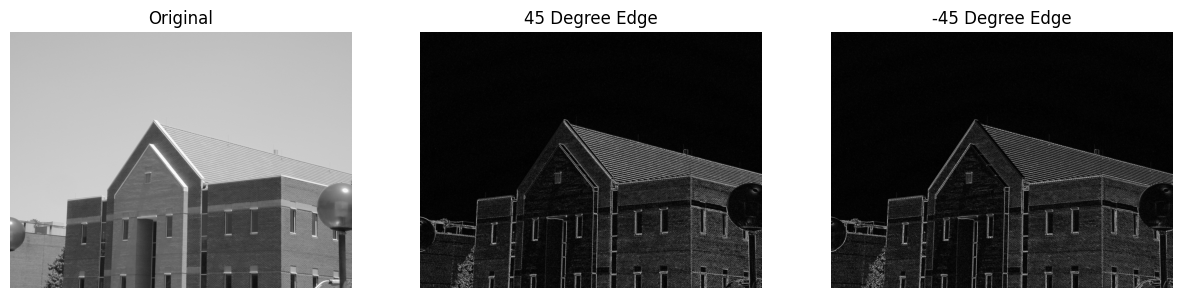

In [55]:
# HW 2-4

img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HW2_data/hw2-4.jpg', cv2.IMREAD_GRAYSCALE)

sobel_45 = np.array([[ 0,  1,  2],
                     [-1,  0,  1],
                     [-2, -1,  0]], dtype=np.float32)

sobel_minus_45 = np.array([[-2, -1,  0],
                           [-1,  0,  1],
                           [ 0,  1,  2]], dtype=np.float32)

edge_45 = cv2.filter2D(img, cv2.CV_64F, sobel_45)
edge_minus_45 = cv2.filter2D(img, cv2.CV_64F, sobel_minus_45)

edge_45 = np.uint8(np.absolute(edge_45))
edge_minus_45 = np.uint8(np.absolute(edge_minus_45))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edge_45, cmap='gray', vmin=0, vmax=255)
plt.title('45 Degree Edge')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edge_minus_45, cmap='gray', vmin=0, vmax=255)
plt.title('-45 Degree Edge')
plt.axis('off')

plt.show()

In [ ]:
# HW 2-5


In [ ]:
# HW 2-6


In [ ]:
# HW 2-7


In [ ]:
# HW 2-8


In [ ]:
# HW 2-9


In [ ]:
# HW 2-10
